<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/notebooks/GVH_GravityTrain_Benchmark_0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Objectif du notebook

Ce notebook construit un benchmark analytique et numérique de GVH Dynamic appliqué au problème du gravity train dans une Terre sphérique.

L’objectif scientifique central est d’étudier la stabilité des observables GVH lorsque la géométrie des trajectoires varie, puis de tester leur sensibilité à une rupture contrôlée de l’invariance harmonique.

Deux modèles sont distingués :

Modèle A — Terre homogène idéale

La densité est constante :

[
\rho(r)=\rho_0.
]

Dans ce cas, le champ gravitationnel intérieur conduit à une dynamique harmonique :

[
\ddot{x}=-\omega^2 x.
]

Les tunnels rectilignes sont représentés par des cordes caractérisées par leur distance minimale au centre :

[
b=0,;0.1R,;0.2R,\ldots,0.9R.
]

Leur longueur géométrique varie selon :

[
L(b)=2\sqrt{R^2-b^2}.
]

Malgré cette variation géométrique, le modèle homogène idéal possède une structure dynamique harmonique commune. Il constitue donc un cas de référence pour tester une éventuelle stabilité des signatures GVH sous variation de la géométrie des trajectoires.

Modèle B — Terre radialement stratifiée

La densité dépend du rayon :

[
\rho=\rho(r).
]

La masse contenue à l’intérieur du rayon (r) est définie par :

[
M(r)=4\pi\int_0^r \rho(s)s^2,ds.
]

L’accélération gravitationnelle intérieure vaut :

[
g(r)=\frac{G,M(r)}{r^2}.
]

Pour un tunnel rectiligne de paramètre d’impact (b), la distance au centre est :

[
r(x)=\sqrt{x^2+b^2},
]

et l’équation du mouvement projetée le long du tunnel devient :

[
\ddot{x}

-\frac{G,M!\left(\sqrt{x^2+b^2}\right)}
{\left(x^2+b^2\right)^{3/2}},x.
]

Contrairement au modèle homogène, cette dynamique n’est généralement plus strictement harmonique.

Le test scientifique central est donc :

[
\boxed{
\text{GVH Dynamic détecte-t-il la rupture de l’invariance harmonique}
}
]

lors du passage :

[
\text{Terre homogène}
\longrightarrow
\text{Terre stratifiée} ; ?
]

Pour chaque tunnel (\mathcal{T}_b), la trajectoire dynamique est représentée par l’état :

[
X_b(t)=
\begin{pmatrix}
x_b(t)\
v_b(t)\
a_b(t)
\end{pmatrix}.
]

Les observables communes de GVH Dynamic sont ensuite calculées :

[
D_T^{\rm mean},
\qquad
S_T,
\qquad
S_T^{\rm norm},
\qquad
D_c,
\qquad
R_{\rm super},
\qquad
A_H,
\qquad
B_H,
]

ainsi que les observables angulaires :

[
\theta_{\rm mean},
\qquad
\theta_{\max},
\qquad
R_{180}.
]

L’hypothèse de référence est :

[
H_0:
\qquad
\mathbf O_{\rm GVH}(b)
\approx
\text{stable}
]

pour la sphère homogène idéale, avec :

[
\mathbf O_{\rm GVH}

\left(
D_T^{\rm mean},
S_T,
S_T^{\rm norm},
D_c,
R_{\rm super},
A_H,
B_H,
\theta_{\rm mean},
\theta_{\max},
R_{180}
\right).
]

L’hypothèse alternative est :

[
H_1:
\qquad
\mathbf O_{\rm GVH}(b)
]

présente une variation systématique avec le paramètre d’impact (b) lorsque la densité terrestre est radialement stratifiée.

La chaîne méthodologique adoptée est :

[
\boxed{
\text{Modèle gravitationnel}
\rightarrow
\text{Trajectoires}
\rightarrow
\text{États dynamiques}
\rightarrow
\text{GVH Dynamic}
\rightarrow
\text{Observables}
}
]

Ce notebook reste volontairement indépendant de toute interprétation par Volume Partagé. Une éventuelle interprétation physique ultérieure pourra être étudiée séparément dans le cadre VP–GVH.

L’objectif de cette version 0.1 est donc de construire un benchmark reproductible permettant de comparer :

[
\boxed{
\text{solution analytique homogène}
\rightarrow
\text{simulation numérique homogène}
\rightarrow
\text{Terre stratifiée}
\rightarrow
\text{rupture éventuelle de signature GVH}
}
]

Cellule 2, code Python.

In [ ]:
# ============================================================
# Cellule 2 — Imports Python et constantes physiques
# GVH_GravityTrain_Pipeline_0.1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# Constantes physiques
# ------------------------------------------------------------

G = 6.67430e-11          # Constante gravitationnelle [m^3 kg^-1 s^-2]
R_EARTH = 6.371e6       # Rayon moyen de la Terre [m]
M_EARTH = 5.9722e24     # Masse moyenne de la Terre [kg]

# Densité moyenne de la Terre homogène équivalente
rho_mean = M_EARTH / ((4/3) * np.pi * R_EARTH**3)

# Pulsation harmonique pour une Terre homogène
omega_uniform = np.sqrt((4 * np.pi * G * rho_mean) / 3)

# Période complète de l’oscillateur harmonique
T_period_uniform = 2 * np.pi / omega_uniform

# Temps de traversée d’un côté à l’autre du tunnel
T_cross_uniform = np.pi / omega_uniform

# ------------------------------------------------------------
# Paramètres numériques du benchmark
# ------------------------------------------------------------

b_values = np.arange(0.0, 1.0, 0.1) * R_EARTH

N_TIME = 2000

t_eval_uniform = np.linspace(0, T_cross_uniform, N_TIME)

# ------------------------------------------------------------
# Affichage de contrôle
# ------------------------------------------------------------

print("Constantes physiques chargées")
print(f"G = {G:.5e} m^3 kg^-1 s^-2")
print(f"R_EARTH = {R_EARTH:.3e} m")
print(f"M_EARTH = {M_EARTH:.3e} kg")
print(f"rho_mean = {rho_mean:.3f} kg/m^3")
print(f"omega_uniform = {omega_uniform:.6e} s^-1")
print(f"T_cross_uniform = {T_cross_uniform/60:.3f} minutes")
print(f"Nombre de tunnels = {len(b_values)}")

Constantes physiques chargées
G = 6.67430e-11 m^3 kg^-1 s^-2
R_EARTH = 6.371e+06 m
M_EARTH = 5.972e+24 kg
rho_mean = 5513.443 kg/m^3
omega_uniform = 1.241534e-03 s^-1
T_cross_uniform = 42.174 minutes
Nombre de tunnels = 10


Cellule 3, code Python.

In [ ]:
# ============================================================
# Cellule 3 — Modèle A : solution analytique homogène
# ============================================================

uniform_trajectories = []

for b in b_values:
    # Demi-longueur du tunnel
    x0 = np.sqrt(R_EARTH**2 - b**2)

    # Solution analytique harmonique
    x = x0 * np.cos(omega_uniform * t_eval_uniform)
    v = -omega_uniform * x0 * np.sin(omega_uniform * t_eval_uniform)
    a = -omega_uniform**2 * x

    # Longueur complète du tunnel
    L = 2 * x0

    df_b = pd.DataFrame({
        "model": "Uniform_Analytic",
        "b_m": b,
        "b_over_R": b / R_EARTH,
        "L_m": L,
        "L_over_R": L / R_EARTH,
        "t_s": t_eval_uniform,
        "t_min": t_eval_uniform / 60,
        "x_m": x,
        "v_m_s": v,
        "a_m_s2": a
    })

    uniform_trajectories.append(df_b)

df_uniform = pd.concat(uniform_trajectories, ignore_index=True)

# ------------------------------------------------------------
# Tableau de contrôle : longueur des tunnels et temps de traversée
# ------------------------------------------------------------

summary_uniform = (
    df_uniform
    .groupby(["b_over_R", "L_over_R"])
    .agg(
        t_start_min=("t_min", "min"),
        t_end_min=("t_min", "max"),
        x_start_m=("x_m", "first"),
        x_end_m=("x_m", "last")
    )
    .reset_index()
)

summary_uniform

,b_over_R,L_over_R,t_start_min,t_end_min,x_start_m,x_end_m
0,0.0,2.000000,0.0,42.173534,6.371000e+06,-6.371000e+06
1,0.1,1.989975,0.0,42.173534,6.339065e+06,-6.339065e+06
2,0.2,1.959592,0.0,42.173534,6.242280e+06,-6.242280e+06
3,0.3,1.907878,0.0,42.173534,6.077547e+06,-6.077547e+06
4,0.4,1.833030,0.0,42.173534,5.839118e+06,-5.839118e+06
5,0.5,1.732051,0.0,42.173534,5.517448e+06,-5.517448e+06
6,0.6,1.600000,0.0,42.173534,5.096800e+06,-5.096800e+06
7,0.7,1.428286,0.0,42.173534,4.549804e+06,-4.549804e+06
8,0.8,1.200000,0.0,42.173534,3.822600e+06,-3.822600e+06
9,0.9,0.871780,0.0,42.173534,2.777055e+06,-2.777055e+06


Cellule 4, code Python.

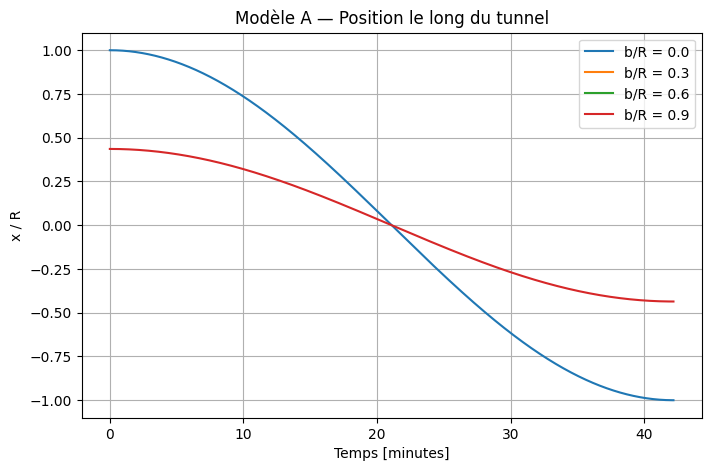

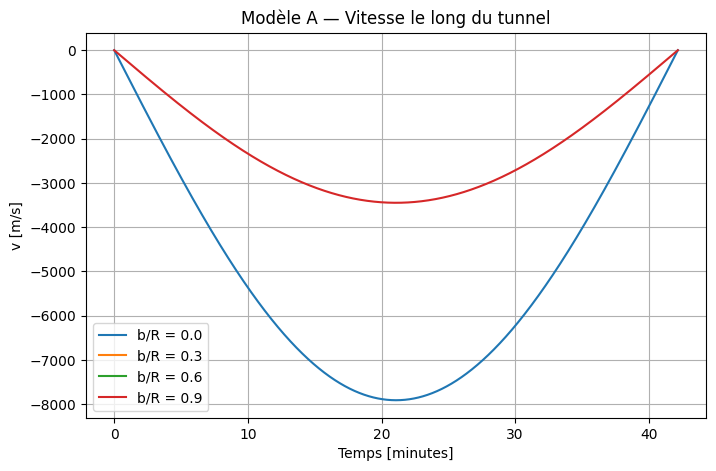

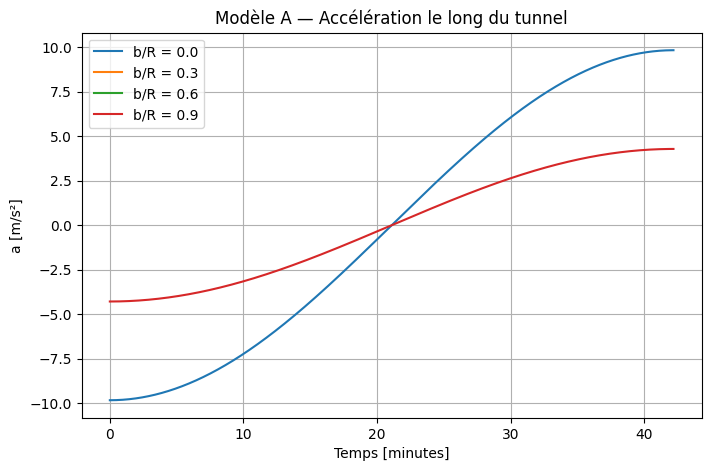

In [ ]:
# ============================================================
# Cellule 4 — Visualisation du Modèle A homogène
# ============================================================

selected_b = [0.0, 0.3, 0.6, 0.9]

df_plot = df_uniform[df_uniform["b_over_R"].isin(selected_b)]

# ------------------------------------------------------------
# Figure 1 — Position x(t)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_plot[df_plot["b_over_R"] == b_ratio]
    plt.plot(sub["t_min"], sub["x_m"] / R_EARTH, label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel("x / R")
plt.title("Modèle A — Position le long du tunnel")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 2 — Vitesse v(t)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_plot[df_plot["b_over_R"] == b_ratio]
    plt.plot(sub["t_min"], sub["v_m_s"], label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel("v [m/s]")
plt.title("Modèle A — Vitesse le long du tunnel")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 3 — Accélération a(t)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_plot[df_plot["b_over_R"] == b_ratio]
    plt.plot(sub["t_min"], sub["a_m_s2"], label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel("a [m/s²]")
plt.title("Modèle A — Accélération le long du tunnel")
plt.legend()
plt.grid(True)
plt.show()

Cellule 5, code Python.

In [ ]:
# ============================================================
# Cellule 5 — Construction du Modèle B stratifié rho(r)
# Version 0.1 : profil radial synthétique inspiré PREM
# ============================================================

# ------------------------------------------------------------
# Grille radiale
# ------------------------------------------------------------

N_R = 5000
r_grid = np.linspace(0, R_EARTH, N_R)

# ------------------------------------------------------------
# Profil de densité stratifié rho(r)
# Approximation simple par couches terrestres
# Unités : kg/m^3
# ------------------------------------------------------------

def rho_stratified(r):
    """
    Profil radial simplifié de densité terrestre.
    r : rayon depuis le centre [m]
    retourne rho(r) [kg/m^3]
    """

    r = np.asarray(r)
    rho = np.zeros_like(r, dtype=float)

    # Rayon normalisé
    u = r / R_EARTH

    # Noyau interne
    mask = u <= 0.191
    rho[mask] = 13000 - 1200 * u[mask]

    # Noyau externe
    mask = (u > 0.191) & (u <= 0.546)
    rho[mask] = 12200 - 4500 * (u[mask] - 0.191) / (0.546 - 0.191)

    # Manteau inférieur
    mask = (u > 0.546) & (u <= 0.895)
    rho[mask] = 5600 - 1200 * (u[mask] - 0.546) / (0.895 - 0.546)

    # Manteau supérieur
    mask = (u > 0.895) & (u <= 0.985)
    rho[mask] = 4400 - 1000 * (u[mask] - 0.895) / (0.985 - 0.895)

    # Croûte
    mask = u > 0.985
    rho[mask] = 3300 - 600 * (u[mask] - 0.985) / (1.000 - 0.985)

    return rho

rho_grid = rho_stratified(r_grid)

# ------------------------------------------------------------
# Normalisation optionnelle de la masse totale
# pour que M(R) = M_EARTH
# ------------------------------------------------------------

integrand_mass = 4 * np.pi * rho_grid * r_grid**2
M_grid_raw = cumulative_trapezoid(integrand_mass, r_grid, initial=0)

mass_scale = M_EARTH / M_grid_raw[-1]

rho_grid = rho_grid * mass_scale

integrand_mass = 4 * np.pi * rho_grid * r_grid**2
M_grid = cumulative_trapezoid(integrand_mass, r_grid, initial=0)

# ------------------------------------------------------------
# Interpolation de rho(r) et M(r)
# ------------------------------------------------------------

rho_interp = interp1d(
    r_grid,
    rho_grid,
    kind="linear",
    bounds_error=False,
    fill_value=(rho_grid[0], rho_grid[-1])
)

M_interp = interp1d(
    r_grid,
    M_grid,
    kind="linear",
    bounds_error=False,
    fill_value=(0.0, M_EARTH)
)

# ------------------------------------------------------------
# Champ gravitationnel intérieur g(r)
# ------------------------------------------------------------

def g_stratified(r):
    """
    Accélération gravitationnelle radiale intérieure.
    r : rayon depuis le centre [m]
    retourne g(r) [m/s^2]
    """

    r = np.asarray(r)
    g = np.zeros_like(r, dtype=float)

    mask = r > 0
    g[mask] = G * M_interp(r[mask]) / r[mask]**2

    return g

g_grid = g_stratified(r_grid)

# ------------------------------------------------------------
# Tableau de contrôle
# ------------------------------------------------------------

summary_stratified = pd.DataFrame({
    "Quantity": [
        "M_raw / M_EARTH avant normalisation",
        "mass_scale",
        "M_final / M_EARTH",
        "rho_center",
        "rho_surface",
        "g_surface"
    ],
    "Value": [
        M_grid_raw[-1] / M_EARTH,
        mass_scale,
        M_grid[-1] / M_EARTH,
        rho_grid[0],
        rho_grid[-1],
        g_grid[-1]
    ]
})

summary_stratified

,Quantity,Value
0,M_raw / M_EARTH avant normalisation,0.963737
1,mass_scale,1.037628
2,M_final / M_EARTH,1.000000
3,rho_center,13489.159607
4,rho_surface,2801.594688
5,g_surface,9.820302


Cellule 6, code Python.

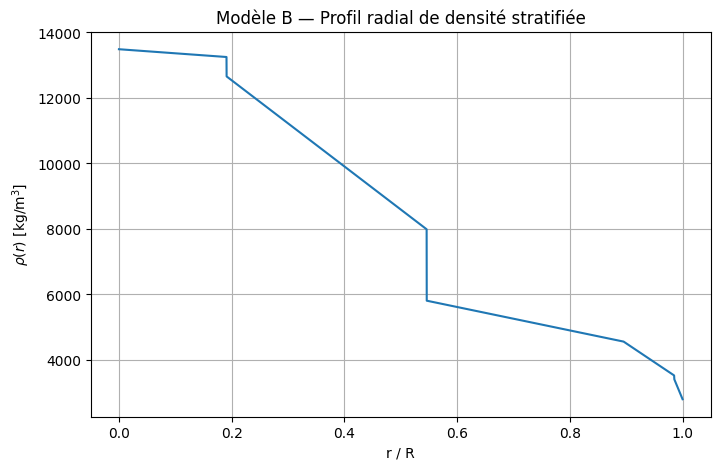

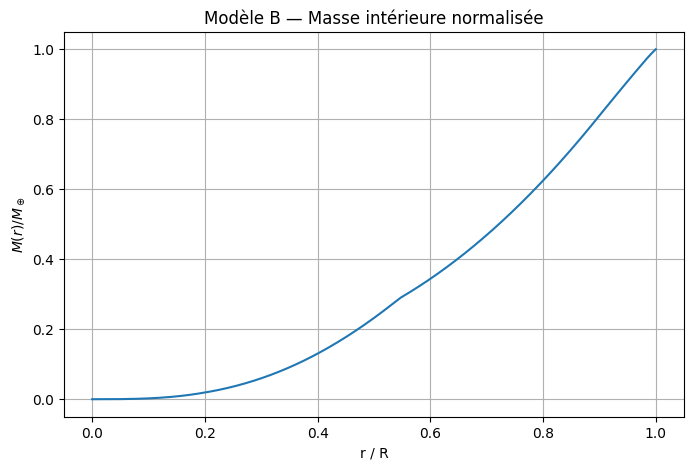

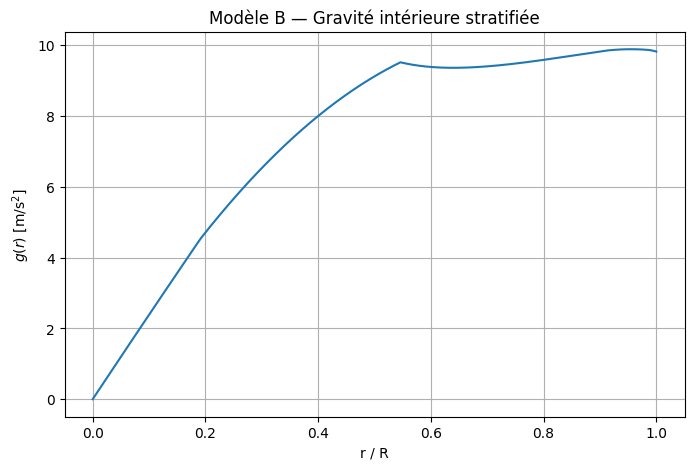

In [ ]:
# ============================================================
# Cellule 6 — Visualisation du Modèle B stratifié
# rho(r), M(r), g(r)
# ============================================================

r_over_R = r_grid / R_EARTH

# ------------------------------------------------------------
# Figure 1 — Profil de densité rho(r)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(r_over_R, rho_grid)
plt.xlabel("r / R")
plt.ylabel(r"$\rho(r)$ [kg/m$^3$]")
plt.title("Modèle B — Profil radial de densité stratifiée")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 2 — Masse intérieure normalisée M(r) / M_EARTH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(r_over_R, M_grid / M_EARTH)
plt.xlabel("r / R")
plt.ylabel(r"$M(r) / M_\oplus$")
plt.title("Modèle B — Masse intérieure normalisée")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 3 — Champ gravitationnel intérieur g(r)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(r_over_R, g_grid)
plt.xlabel("r / R")
plt.ylabel(r"$g(r)$ [m/s$^2$]")
plt.title("Modèle B — Gravité intérieure stratifiée")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Cellule 7 — Équation du mouvement dans un tunnel stratifié
# Modèle B : Terre radialement stratifiée
# ============================================================

def r_of_x_b(x, b):
    """
    Distance au centre de la Terre pour une position x
    le long d'un tunnel de paramètre d'impact b.

    x : position le long du tunnel [m]
    b : distance minimale au centre [m]
    """
    return np.sqrt(x**2 + b**2)


def a_x_stratified(x, b):
    """
    Accélération projetée le long du tunnel pour le Modèle B.

    Equation :
        x_ddot = - G M(r) x / r^3

    avec :
        r = sqrt(x^2 + b^2)

    x : position le long du tunnel [m]
    b : paramètre d'impact [m]

    retourne a_x [m/s^2]
    """

    x = np.asarray(x, dtype=float)
    r = r_of_x_b(x, b)

    a = np.zeros_like(x, dtype=float)

    mask = r > 0
    a[mask] = -G * M_interp(r[mask]) * x[mask] / r[mask]**3

    return a


# ------------------------------------------------------------
# Vérification numérique simple
# ------------------------------------------------------------

test_rows = []

for b in b_values:
    x0 = np.sqrt(R_EARTH**2 - b**2)

    a_start = a_x_stratified(np.array([x0]), b)[0]
    a_center = a_x_stratified(np.array([0.0]), b)[0]
    a_end = a_x_stratified(np.array([-x0]), b)[0]

    test_rows.append({
        "b_over_R": b / R_EARTH,
        "x0_over_R": x0 / R_EARTH,
        "a_start_m_s2": a_start,
        "a_center_m_s2": a_center,
        "a_end_m_s2": a_end
    })

summary_ax_stratified = pd.DataFrame(test_rows)

summary_ax_stratified

,b_over_R,x0_over_R,a_start_m_s2,a_center_m_s2,a_end_m_s2
0,0.0,1.000000,-9.820302,0.0,9.820302
1,0.1,0.994987,-9.771077,-0.0,9.771077
2,0.2,0.979796,-9.621892,-0.0,9.621892
3,0.3,0.953939,-9.367971,-0.0,9.367971
4,0.4,0.916515,-9.000456,-0.0,9.000456
5,0.5,0.866025,-8.504631,-0.0,8.504631
6,0.6,0.800000,-7.856242,-0.0,7.856242
7,0.7,0.714143,-7.013099,-0.0,7.013099
8,0.8,0.600000,-5.892181,-0.0,5.892181
9,0.9,0.435890,-4.280571,-0.0,4.280571


Cellule 8, code Python.

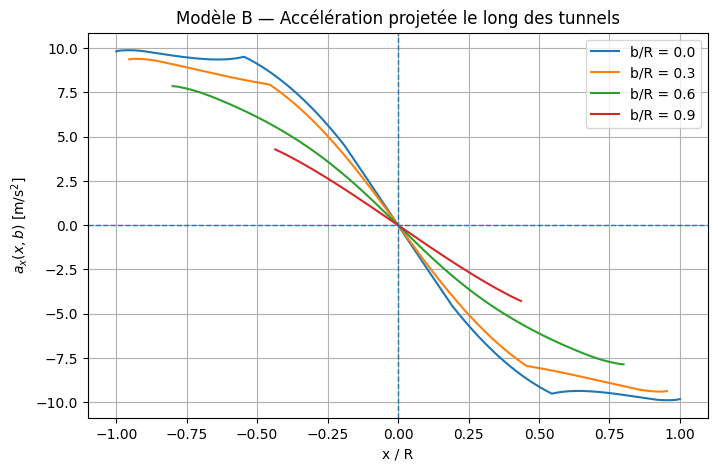

In [ ]:
# ============================================================
# Cellule 8 — Visualisation de a_x(x,b) pour plusieurs tunnels
# Modèle B stratifié
# ============================================================

selected_b = [0.0, 0.3, 0.6, 0.9]

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    b = b_ratio * R_EARTH
    x0 = np.sqrt(R_EARTH**2 - b**2)

    x_line = np.linspace(-x0, x0, 1000)
    a_line = a_x_stratified(x_line, b)

    plt.plot(
        x_line / R_EARTH,
        a_line,
        label=f"b/R = {b_ratio:.1f}"
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("x / R")
plt.ylabel(r"$a_x(x,b)$ [m/s$^2$]")
plt.title("Modèle B — Accélération projetée le long des tunnels")
plt.legend()
plt.grid(True)
plt.show()

Cellule 9, code Python.

In [ ]:
# ============================================================
# Cellule 9 — Intégration numérique robuste du Modèle B
# Détection par point de retournement : v passe de - à +
# ============================================================

def a_x_stratified_safe(x, b):
    x = np.asarray(x, dtype=float)
    r = r_of_x_b(x, b)

    a = np.zeros_like(x, dtype=float)
    r_eps = r_grid[1]

    mask_regular = r >= r_eps
    a[mask_regular] = -G * M_interp(r[mask_regular]) * x[mask_regular] / r[mask_regular]**3

    mask_center = r < r_eps
    rho_c = rho_grid[0]
    omega_c2 = 4 * np.pi * G * rho_c / 3
    a[mask_center] = -omega_c2 * x[mask_center]

    return a


def rhs_stratified(t, y, b):
    x, v = y
    a = a_x_stratified_safe(np.array([x]), b)[0]
    return [v, a]


stratified_trajectories = []
crossing_rows = []

for b in b_values:
    x0 = np.sqrt(R_EARTH**2 - b**2)
    y0 = [x0, 0.0]

    t_max = 3 * 3600
    t_dense = np.linspace(0, t_max, 30000)

    sol = solve_ivp(
        fun=lambda t, y: rhs_stratified(t, y, b),
        t_span=(0, t_max),
        y0=y0,
        t_eval=t_dense,
        rtol=1e-9,
        atol=1e-9,
        max_step=1.0
    )

    t_all = sol.t
    x_all = sol.y[0]
    v_all = sol.y[1]

    # Chercher le premier retournement après le départ :
    # v passe de négatif à positif
    idx = np.where((v_all[:-1] < 0) & (v_all[1:] >= 0))[0]

    if len(idx) > 0:
        k = idx[0]

        t1, t2 = t_all[k], t_all[k+1]
        v1, v2 = v_all[k], v_all[k+1]

        # interpolation linéaire du temps où v = 0
        t_cross = t1 - v1 * (t2 - t1) / (v2 - v1)

        reached = True

        t_eval_b = np.linspace(0, t_cross, N_TIME)

        x = np.interp(t_eval_b, t_all, x_all)
        v = np.interp(t_eval_b, t_all, v_all)
        a = a_x_stratified_safe(x, b)

        L = 2 * x0

        df_b = pd.DataFrame({
            "model": "Stratified_Numeric",
            "b_m": b,
            "b_over_R": b / R_EARTH,
            "L_m": L,
            "L_over_R": L / R_EARTH,
            "t_s": t_eval_b,
            "t_min": t_eval_b / 60,
            "x_m": x,
            "v_m_s": v,
            "a_m_s2": a
        })

        stratified_trajectories.append(df_b)

    else:
        t_cross = np.nan
        reached = False

    crossing_rows.append({
        "b_over_R": b / R_EARTH,
        "L_over_R": 2 * x0 / R_EARTH,
        "T_cross_min": t_cross / 60 if reached else np.nan,
        "T_cross_uniform_min": T_cross_uniform / 60,
        "Delta_T_min": (t_cross - T_cross_uniform) / 60 if reached else np.nan,
        "x_min_over_R": np.min(x_all) / R_EARTH,
        "v_min_m_s": np.min(v_all),
        "reached_turning_point": reached,
        "solver_success": sol.success
    })

summary_crossing_stratified = pd.DataFrame(crossing_rows)

df_stratified = pd.concat(stratified_trajectories, ignore_index=True)

summary_crossing_stratified

,b_over_R,L_over_R,T_cross_min,T_cross_uniform_min,Delta_T_min,x_min_over_R,v_min_m_s,reached_turning_point,solver_success
0,0.0,2.000000,38.661304,42.173534,-3.512230,-1.000000,-9717.323467,True,True
1,0.1,1.989975,38.708985,42.173534,-3.464549,-0.994987,-9638.602448,True,True
2,0.2,1.959592,38.851846,42.173534,-3.321688,-0.979796,-9400.088286,True,True
3,0.3,1.907878,39.084687,42.173534,-3.088847,-0.953939,-9009.190737,True,True
4,0.4,1.833030,39.400967,42.173534,-2.772568,-0.916515,-8477.767167,True,True
5,0.5,1.732051,39.792468,42.173534,-2.381066,-0.866025,-7805.681657,True,True
6,0.6,1.600000,40.226347,42.173534,-1.947188,-0.800000,-6997.712006,True,True
7,0.7,1.428286,40.655846,42.173534,-1.517688,-0.714143,-6084.797626,True,True
8,0.8,1.200000,41.092481,42.173534,-1.081054,-0.600000,-4993.793504,True,True
9,0.9,0.871780,41.568043,42.173534,-0.605491,-0.435890,-3545.896337,True,True


Cellule 10, code Python.

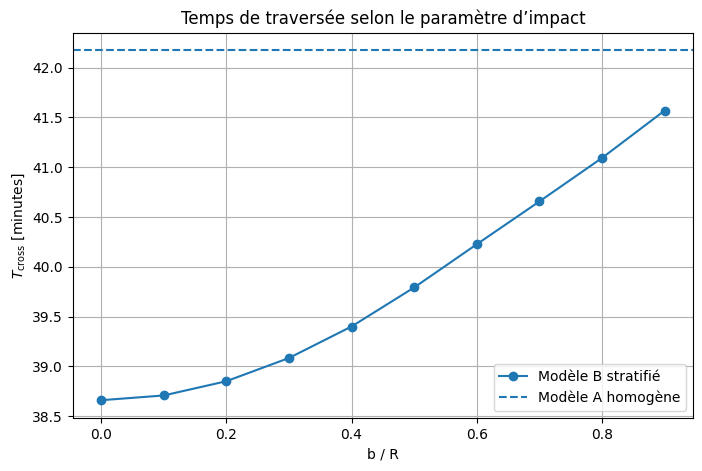

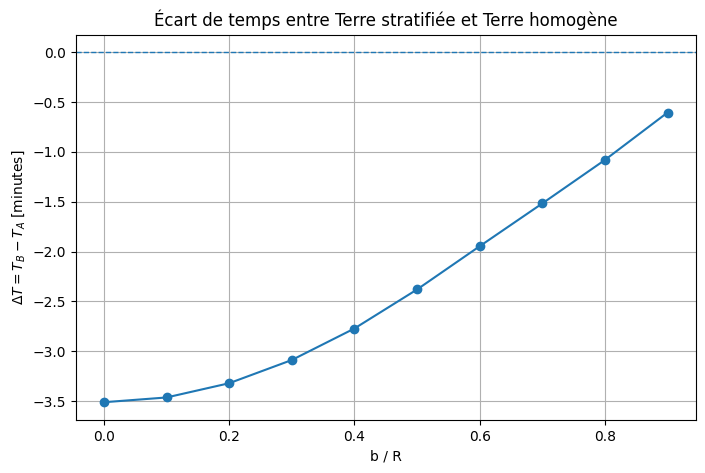

In [ ]:
# ============================================================
# Cellule 10 — Visualisation des temps de traversée T_cross(b)
# Comparaison Modèle A homogène vs Modèle B stratifié
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    summary_crossing_stratified["b_over_R"],
    summary_crossing_stratified["T_cross_min"],
    marker="o",
    label="Modèle B stratifié"
)

plt.axhline(
    T_cross_uniform / 60,
    linestyle="--",
    label="Modèle A homogène"
)

plt.xlabel("b / R")
plt.ylabel(r"$T_{\rm cross}$ [minutes]")
plt.title("Temps de traversée selon le paramètre d’impact")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Figure 2 — Écart au modèle homogène
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    summary_crossing_stratified["b_over_R"],
    summary_crossing_stratified["Delta_T_min"],
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("b / R")
plt.ylabel(r"$\Delta T = T_B - T_A$ [minutes]")
plt.title("Écart de temps entre Terre stratifiée et Terre homogène")
plt.grid(True)
plt.show()

Cellule 11, code Python.

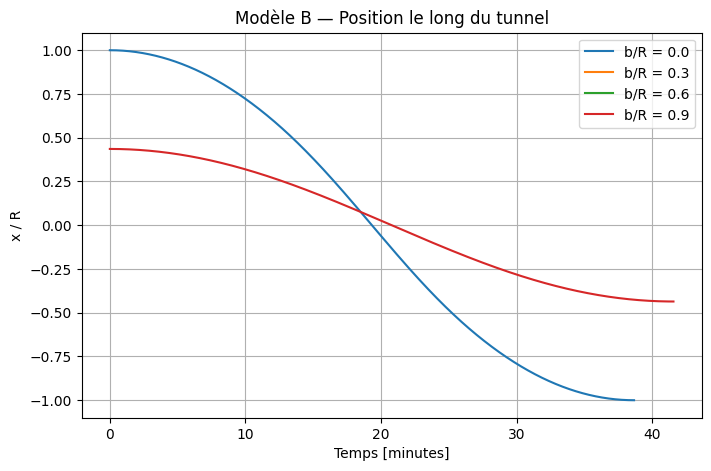

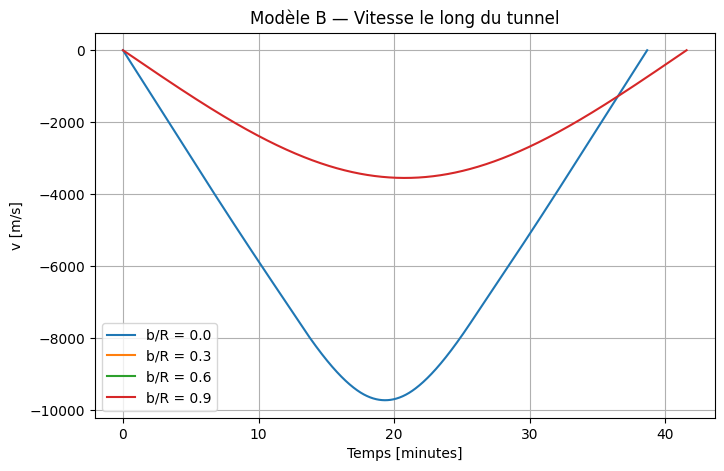

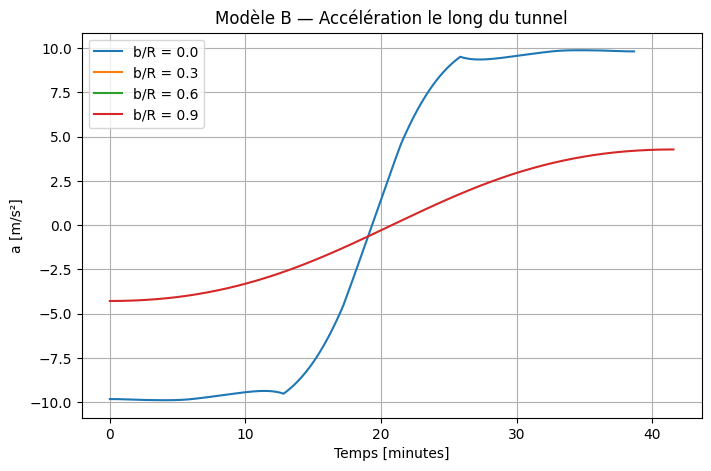

In [ ]:
# ============================================================
# Cellule 11 — Visualisation des trajectoires dynamiques
# Modèle B stratifié : x(t), v(t), a(t)
# ============================================================

selected_b = [0.0, 0.3, 0.6, 0.9]

df_plot_B = df_stratified[df_stratified["b_over_R"].isin(selected_b)]

# ------------------------------------------------------------
# Figure 1 — Position x(t)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_plot_B[df_plot_B["b_over_R"] == b_ratio]
    plt.plot(sub["t_min"], sub["x_m"] / R_EARTH, label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel("x / R")
plt.title("Modèle B — Position le long du tunnel")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 2 — Vitesse v(t)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_plot_B[df_plot_B["b_over_R"] == b_ratio]
    plt.plot(sub["t_min"], sub["v_m_s"], label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel("v [m/s]")
plt.title("Modèle B — Vitesse le long du tunnel")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Figure 3 — Accélération a(t)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_plot_B[df_plot_B["b_over_R"] == b_ratio]
    plt.plot(sub["t_min"], sub["a_m_s2"], label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel("a [m/s²]")
plt.title("Modèle B — Accélération le long du tunnel")
plt.legend()
plt.grid(True)
plt.show()

Cellule 12, code Python.

In [ ]:
# ============================================================
# Cellule 12 — Validation numérique et énergétique du Modèle B
# ============================================================

# ------------------------------------------------------------
# 1. Potentiel gravitationnel intérieur spécifique Phi(r)
#
# Convention :
#   Phi(R) = -G M_EARTH / R_EARTH
#
# et :
#   dPhi/dr = g(r)
#
# donc :
#   Phi(r) = Phi(R) - integral_r^R g(s) ds
#
# Unité : J/kg = m^2/s^2
# ------------------------------------------------------------

Phi_surface = -G * M_EARTH / R_EARTH

# Intégrale cumulative depuis le centre :
# I(r) = integral_0^r g(s) ds
I_g = cumulative_trapezoid(g_grid, r_grid, initial=0.0)

# Phi(r) = Phi(R) - integral_r^R g(s) ds
Phi_grid = Phi_surface - (I_g[-1] - I_g)

Phi_interp = interp1d(
    r_grid,
    Phi_grid,
    kind="linear",
    bounds_error=False,
    fill_value=(Phi_grid[0], Phi_grid[-1])
)


# ------------------------------------------------------------
# 2. Validation tunnel par tunnel
# ------------------------------------------------------------

validation_rows = []
energy_profiles = []

for b in b_values:

    b_ratio = b / R_EARTH
    x0 = np.sqrt(R_EARTH**2 - b**2)

    sub = (
        df_stratified[
            np.isclose(
                df_stratified["b_over_R"],
                b_ratio,
                atol=1e-12
            )
        ]
        .sort_values("t_s")
        .copy()
    )

    if len(sub) == 0:
        continue

    t = sub["t_s"].to_numpy()
    x = sub["x_m"].to_numpy()
    v = sub["v_m_s"].to_numpy()

    # Rayon géocentrique le long du tunnel
    r = np.sqrt(x**2 + b**2)

    # --------------------------------------------------------
    # Énergie mécanique spécifique
    # e = 1/2 v^2 + Phi(r)
    # --------------------------------------------------------

    Phi = Phi_interp(r)
    E_spec = 0.5 * v**2 + Phi

    E0 = E_spec[0]

    # Erreurs énergétiques
    delta_E = E_spec - E0

    E_abs_scale = max(abs(E0), 1.0)

    max_abs_dE = np.max(np.abs(delta_E))
    max_rel_dE = max_abs_dE / E_abs_scale

    rms_abs_dE = np.sqrt(np.mean(delta_E**2))
    rms_rel_dE = rms_abs_dE / E_abs_scale

    # --------------------------------------------------------
    # Validation du retournement opposé
    # --------------------------------------------------------

    x_final = x[-1]
    v_final = v[-1]

    # Erreur absolue :
    # x_final doit être proche de -x0
    turning_error_m = abs(x_final + x0)

    # Erreur relative à la demi-longueur du tunnel
    turning_error_rel = turning_error_m / x0

    # Symétrie des amplitudes :
    # |x_final| / x0 doit être proche de 1
    amplitude_ratio = abs(x_final) / x0

    # --------------------------------------------------------
    # Stockage résumé
    # --------------------------------------------------------

    validation_rows.append({
        "b_over_R": b_ratio,
        "x0_over_R": x0 / R_EARTH,
        "x_final_over_R": x_final / R_EARTH,
        "turning_error_m": turning_error_m,
        "turning_error_rel": turning_error_rel,
        "amplitude_ratio": amplitude_ratio,
        "v_final_m_s": v_final,
        "E0_J_kg": E0,
        "max_abs_dE_J_kg": max_abs_dE,
        "max_rel_dE": max_rel_dE,
        "rms_rel_dE": rms_rel_dE
    })

    # Profil énergétique complet
    df_energy_b = pd.DataFrame({
        "b_over_R": b_ratio,
        "t_s": t,
        "t_min": t / 60,
        "x_m": x,
        "r_m": r,
        "v_m_s": v,
        "Phi_J_kg": Phi,
        "E_spec_J_kg": E_spec,
        "Delta_E_J_kg": delta_E,
        "Delta_E_rel": delta_E / E_abs_scale
    })

    energy_profiles.append(df_energy_b)


# ------------------------------------------------------------
# 3. Tables finales
# ------------------------------------------------------------

summary_validation_B = pd.DataFrame(validation_rows)

if len(energy_profiles) > 0:
    df_energy_B = pd.concat(
        energy_profiles,
        ignore_index=True
    )
else:
    df_energy_B = pd.DataFrame()


# ------------------------------------------------------------
# 4. Affichage du tableau de validation
# ------------------------------------------------------------

summary_validation_B

,b_over_R,x0_over_R,x_final_over_R,turning_error_m,turning_error_rel,amplitude_ratio,v_final_m_s,E0_J_kg,max_abs_dE_J_kg,max_rel_dE,rms_rel_dE
0,0.0,1.000000,-1.000000,0.608957,9.558261e-08,1.0,2.058798e-12,-6.256515e+07,18.390277,2.939380e-07,6.273012e-08
1,0.1,0.994987,-0.994987,0.114645,1.808553e-08,1.0,-2.210898e-12,-6.256515e+07,4.884203,7.806589e-08,1.884336e-08
2,0.2,0.979796,-0.979796,0.109871,1.760103e-08,1.0,1.498968e-12,-6.256515e+07,3.172577,5.070837e-08,2.424592e-08
3,0.3,0.953939,-0.953939,0.092880,1.528247e-08,1.0,4.973799e-13,-6.256515e+07,3.086664,4.933520e-08,2.128480e-08
4,0.4,0.916515,-0.916515,0.159194,2.726331e-08,1.0,1.879163e-12,-6.256515e+07,2.944419,4.706165e-08,1.950559e-08
5,0.5,0.866025,-0.866025,0.071024,1.287265e-08,1.0,1.426415e-12,-6.256515e+07,2.320173,3.708411e-08,1.606539e-08
6,0.6,0.800000,-0.800000,0.070814,1.389376e-08,1.0,-1.274869e-12,-6.256515e+07,1.659548,2.652511e-08,1.291683e-08
7,0.7,0.714143,-0.714143,0.085363,1.876191e-08,1.0,5.409007e-13,-6.256515e+07,1.034323,1.653193e-08,9.621667e-09
8,0.8,0.600000,-0.600000,0.095288,2.492746e-08,1.0,-7.098766e-13,-6.256515e+07,0.708611,1.132597e-08,6.540942e-09
9,0.9,0.435890,-0.435890,0.048135,1.733311e-08,1.0,6.203926e-13,-6.256515e+07,0.442170,7.067347e-09,3.641239e-09


Cellule 13, cellule code Python.

In [ ]:
# ============================================================
# Cellule 13 — Construction des états dynamiques GVH
# X_b(t) = (x, v, a) avec normalisation
# ============================================================

def build_gvh_states(df, model_name):
    """
    Construit les états dynamiques normalisés GVH
    à partir d'un dataframe de trajectoires.

    État brut :
        X(t) = (x, v, a)

    État normalisé :
        X_norm(t) = (x/R, v/v_scale, a/a_scale)
    """

    df_out = df.copy()

    # Échelles physiques globales
    x_scale = R_EARTH
    v_scale = np.sqrt(G * M_EARTH / R_EARTH)
    a_scale = G * M_EARTH / R_EARTH**2

    df_out["x_norm"] = df_out["x_m"] / x_scale
    df_out["v_norm"] = df_out["v_m_s"] / v_scale
    df_out["a_norm"] = df_out["a_m_s2"] / a_scale

    df_out["model_gvh"] = model_name

    return df_out


df_uniform_gvh = build_gvh_states(
    df_uniform,
    model_name="Uniform_Analytic"
)

df_stratified_gvh = build_gvh_states(
    df_stratified,
    model_name="Stratified_Numeric"
)

# ------------------------------------------------------------
# Tableau de contrôle des bornes normalisées
# ------------------------------------------------------------

summary_gvh_states = pd.DataFrame({
    "Model": ["Uniform_Analytic", "Stratified_Numeric"],
    "x_norm_min": [
        df_uniform_gvh["x_norm"].min(),
        df_stratified_gvh["x_norm"].min()
    ],
    "x_norm_max": [
        df_uniform_gvh["x_norm"].max(),
        df_stratified_gvh["x_norm"].max()
    ],
    "v_norm_min": [
        df_uniform_gvh["v_norm"].min(),
        df_stratified_gvh["v_norm"].min()
    ],
    "v_norm_max": [
        df_uniform_gvh["v_norm"].max(),
        df_stratified_gvh["v_norm"].max()
    ],
    "a_norm_min": [
        df_uniform_gvh["a_norm"].min(),
        df_stratified_gvh["a_norm"].min()
    ],
    "a_norm_max": [
        df_uniform_gvh["a_norm"].max(),
        df_stratified_gvh["a_norm"].max()
    ]
})

summary_gvh_states

,Model,x_norm_min,x_norm_max,v_norm_min,v_norm_max,a_norm_min,a_norm_max
0,Uniform_Analytic,-1.0,1.0,-1.000000,-0.000000e+00,-1.000000,1.000000
1,Stratified_Numeric,-1.0,1.0,-1.228514,2.602840e-16,-1.006728,1.006728


Cellule 14, code Python.

In [ ]:
# ============================================================
# Cellule 14 — Calcul de D_T tunnel par tunnel
# ============================================================

def compute_DT_by_tunnel(df_gvh):
    """
    Calcule D_T(t) = ||X(t+dt) - X(t)|| pour chaque tunnel b.

    État GVH normalisé :
        X(t) = (x_norm, v_norm, a_norm)

    Retourne un dataframe contenant D_T pour chaque pas temporel.
    """

    DT_rows = []

    for b_ratio, sub in df_gvh.groupby("b_over_R"):
        sub = sub.sort_values("t_s").reset_index(drop=True)

        X = sub[["x_norm", "v_norm", "a_norm"]].to_numpy()

        dX = np.diff(X, axis=0)
        D_T = np.linalg.norm(dX, axis=1)

        t_mid = 0.5 * (
            sub["t_s"].to_numpy()[1:] +
            sub["t_s"].to_numpy()[:-1]
        )

        DT_rows.append(pd.DataFrame({
            "model_gvh": sub["model_gvh"].iloc[0],
            "b_over_R": b_ratio,
            "t_s": t_mid,
            "t_min": t_mid / 60,
            "D_T": D_T
        }))

    return pd.concat(DT_rows, ignore_index=True)


df_DT_uniform = compute_DT_by_tunnel(df_uniform_gvh)
df_DT_stratified = compute_DT_by_tunnel(df_stratified_gvh)

df_DT_all = pd.concat(
    [df_DT_uniform, df_DT_stratified],
    ignore_index=True
)

# ------------------------------------------------------------
# Résumé tunnel par tunnel
# ------------------------------------------------------------

summary_DT_by_tunnel = (
    df_DT_all
    .groupby(["model_gvh", "b_over_R"])
    .agg(
        D_T_mean=("D_T", "mean"),
        D_T_std=("D_T", "std"),
        D_T_min=("D_T", "min"),
        D_T_max=("D_T", "max")
    )
    .reset_index()
)

summary_DT_by_tunnel

,model_gvh,b_over_R,D_T_mean,D_T_std,D_T_min,D_T_max
0,Stratified_Numeric,0.0,0.002259,0.001028,0.001441,0.004933
1,Stratified_Numeric,0.1,0.002238,0.001006,0.001435,0.004618
2,Stratified_Numeric,0.2,0.002177,0.000941,0.001419,0.004470
3,Stratified_Numeric,0.3,0.002079,0.000843,0.001389,0.004033
4,Stratified_Numeric,0.4,0.001951,0.000719,0.001346,0.003570
5,Stratified_Numeric,0.5,0.001798,0.000566,0.001284,0.003087
6,Stratified_Numeric,0.6,0.001625,0.000411,0.001199,0.002494
7,Stratified_Numeric,0.7,0.001426,0.000300,0.001082,0.001975
8,Stratified_Numeric,0.8,0.001181,0.000212,0.000919,0.001525
9,Stratified_Numeric,0.9,0.000846,0.000129,0.000675,0.001038


Cellule 15,  code Python.

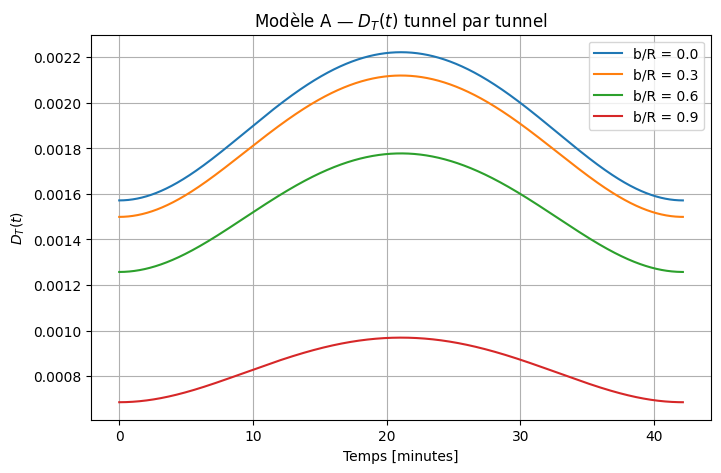

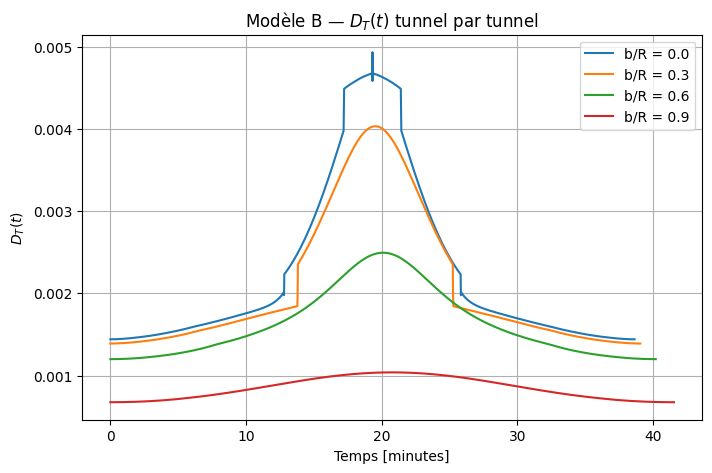

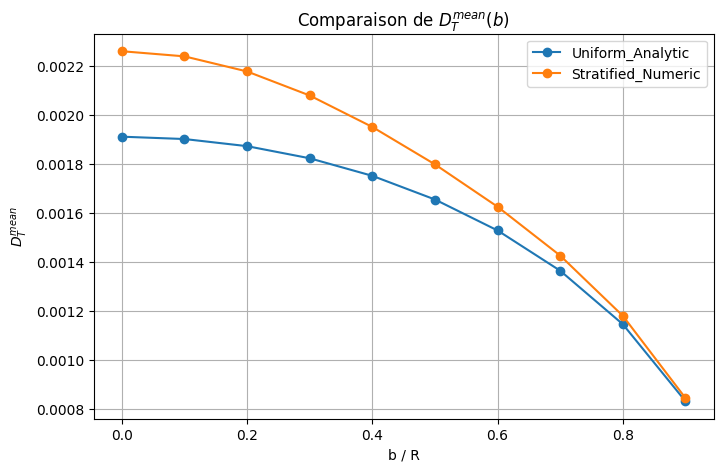

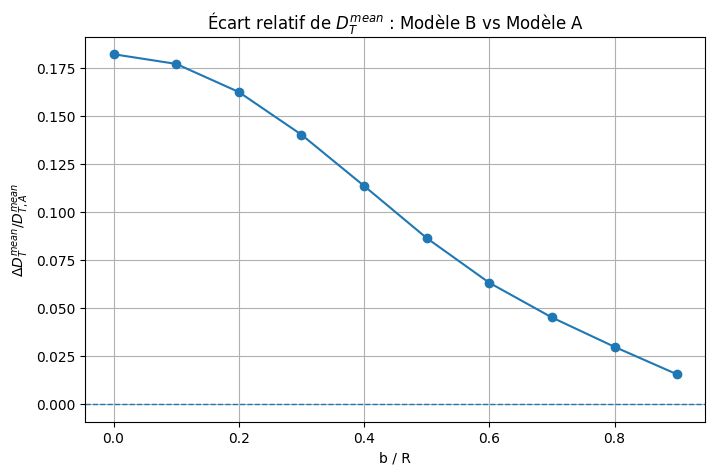

,b_over_R,D_T_mean_A,D_T_mean_B,Delta_D_T_mean,Delta_D_T_mean_rel
0,0.0,0.001911,0.002259,0.000348,0.182233
1,0.1,0.001901,0.002238,0.000337,0.177193
2,0.2,0.001872,0.002177,0.000304,0.162556
3,0.3,0.001823,0.002079,0.000256,0.140341
4,0.4,0.001752,0.001951,0.000199,0.113672
5,0.5,0.001655,0.001798,0.000143,0.086519
6,0.6,0.001529,0.001625,0.000097,0.063220
7,0.7,0.001365,0.001426,0.000062,0.045165
8,0.8,0.001147,0.001181,0.000034,0.029872
9,0.9,0.000833,0.000846,0.000013,0.015535


In [ ]:
# ============================================================
# Cellule 15 — Visualisation de D_T(t) et D_T_mean(b)
# ============================================================

selected_b = [0.0, 0.3, 0.6, 0.9]

# ------------------------------------------------------------
# Figure 1 — D_T(t), Modèle A homogène
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_DT_uniform[np.isclose(df_DT_uniform["b_over_R"], b_ratio)]
    plt.plot(sub["t_min"], sub["D_T"], label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel(r"$D_T(t)$")
plt.title(r"Modèle A — $D_T(t)$ tunnel par tunnel")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Figure 2 — D_T(t), Modèle B stratifié
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for b_ratio in selected_b:
    sub = df_DT_stratified[np.isclose(df_DT_stratified["b_over_R"], b_ratio)]
    plt.plot(sub["t_min"], sub["D_T"], label=f"b/R = {b_ratio:.1f}")

plt.xlabel("Temps [minutes]")
plt.ylabel(r"$D_T(t)$")
plt.title(r"Modèle B — $D_T(t)$ tunnel par tunnel")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Figure 3 — D_T_mean(b), comparaison A vs B
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for model_name in ["Uniform_Analytic", "Stratified_Numeric"]:
    sub = summary_DT_by_tunnel[
        summary_DT_by_tunnel["model_gvh"] == model_name
    ]

    plt.plot(
        sub["b_over_R"],
        sub["D_T_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("b / R")
plt.ylabel(r"$D_T^{mean}$")
plt.title(r"Comparaison de $D_T^{mean}(b)$")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Figure 4 — Écart relatif de D_T_mean
# ------------------------------------------------------------

dt_uniform_mean = (
    summary_DT_by_tunnel[
        summary_DT_by_tunnel["model_gvh"] == "Uniform_Analytic"
    ][["b_over_R", "D_T_mean"]]
    .rename(columns={"D_T_mean": "D_T_mean_A"})
)

dt_strat_mean = (
    summary_DT_by_tunnel[
        summary_DT_by_tunnel["model_gvh"] == "Stratified_Numeric"
    ][["b_over_R", "D_T_mean"]]
    .rename(columns={"D_T_mean": "D_T_mean_B"})
)

df_DT_compare = pd.merge(
    dt_uniform_mean,
    dt_strat_mean,
    on="b_over_R"
)

df_DT_compare["Delta_D_T_mean"] = (
    df_DT_compare["D_T_mean_B"]
    - df_DT_compare["D_T_mean_A"]
)

df_DT_compare["Delta_D_T_mean_rel"] = (
    df_DT_compare["Delta_D_T_mean"]
    / df_DT_compare["D_T_mean_A"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    df_DT_compare["b_over_R"],
    df_DT_compare["Delta_D_T_mean_rel"],
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("b / R")
plt.ylabel(r"$\Delta D_T^{mean} / D_{T,A}^{mean}$")
plt.title(r"Écart relatif de $D_T^{mean}$ : Modèle B vs Modèle A")
plt.grid(True)
plt.show()

df_DT_compare

Cellule 16, code Python.

In [ ]:
# ============================================================
# Cellule 16 — Observables globales GVH par modèle
# D_T_mean, S_T, S_T_norm, D_c, R_super
# ============================================================

def compute_global_gvh_observables(df_DT, model_name, q_c=0.90):
    """
    Calcule les observables globales GVH à partir de D_T.

    Observables :
        D_T_mean  = moyenne de D_T
        S_T       = écart-type de D_T
        S_T_norm  = S_T / D_T_mean
        D_c       = quantile q_c de D_T
        R_super   = fraction des D_T > D_c
    """

    D = df_DT["D_T"].to_numpy()

    D_T_mean = np.mean(D)
    S_T = np.std(D, ddof=1)
    S_T_norm = S_T / D_T_mean if D_T_mean != 0 else np.nan

    D_c = np.quantile(D, q_c)
    R_super = np.mean(D > D_c)

    return {
        "Model": model_name,
        "q_c": q_c,
        "N_D": len(D),
        "D_T_mean": D_T_mean,
        "S_T": S_T,
        "S_T_norm": S_T_norm,
        "D_c": D_c,
        "R_super": R_super
    }


obs_uniform_global = compute_global_gvh_observables(
    df_DT_uniform,
    model_name="Uniform_Analytic",
    q_c=0.90
)

obs_stratified_global = compute_global_gvh_observables(
    df_DT_stratified,
    model_name="Stratified_Numeric",
    q_c=0.90
)

summary_global_gvh = pd.DataFrame([
    obs_uniform_global,
    obs_stratified_global
])

summary_global_gvh

,Model,q_c,N_D,D_T_mean,S_T,S_T_norm,D_c,R_super
0,Uniform_Analytic,0.9,19990,0.001579,0.000395,0.250495,0.002096,0.1
1,Stratified_Numeric,0.9,19990,0.001758,0.000831,0.472850,0.003042,0.1


Cellule 17, code Python.

In [ ]:
# ============================================================
# Cellule 17 — Loi de queue GVH
# R_super(D_c) ≈ A_H exp(-B_H D_c)
# ============================================================

def exp_tail_law(D_c, A_H, B_H):
    return A_H * np.exp(-B_H * D_c)


def compute_tail_law(df_DT, model_name, q_values=None):
    """
    Calcule R_super(D_c) pour plusieurs quantiles,
    puis ajuste :
        R_super(D_c) = A_H exp(-B_H D_c)
    """

    if q_values is None:
        q_values = np.linspace(0.50, 0.99, 30)

    D = df_DT["D_T"].to_numpy()

    rows = []

    for q in q_values:
        D_c = np.quantile(D, q)
        R_super = np.mean(D > D_c)

        rows.append({
            "Model": model_name,
            "q": q,
            "D_c": D_c,
            "R_super": R_super
        })

    df_tail = pd.DataFrame(rows)

    # Ajustement exponentiel
    x = df_tail["D_c"].to_numpy()
    y = df_tail["R_super"].to_numpy()

    popt, pcov = curve_fit(
        exp_tail_law,
        x,
        y,
        p0=[1.0, 500.0],
        maxfev=10000
    )

    A_H, B_H = popt

    y_fit = exp_tail_law(x, A_H, B_H)

    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    R2 = 1 - ss_res / ss_tot

    summary = {
        "Model": model_name,
        "A_H": A_H,
        "B_H": B_H,
        "R2_tail_fit": R2,
        "D_c_min": np.min(x),
        "D_c_max": np.max(x)
    }

    df_tail["R_super_fit"] = y_fit

    return df_tail, summary


df_tail_uniform, summary_tail_uniform = compute_tail_law(
    df_DT_uniform,
    model_name="Uniform_Analytic"
)

df_tail_stratified, summary_tail_stratified = compute_tail_law(
    df_DT_stratified,
    model_name="Stratified_Numeric"
)

df_tail_all = pd.concat(
    [df_tail_uniform, df_tail_stratified],
    ignore_index=True
)

summary_tail_gvh = pd.DataFrame([
    summary_tail_uniform,
    summary_tail_stratified
])

summary_tail_gvh

,Model,A_H,B_H,R2_tail_fit,D_c_min,D_c_max
0,Uniform_Analytic,68.142266,3025.666037,0.959919,0.001599,0.002211
1,Stratified_Numeric,3.526869,1343.733131,0.956753,0.001523,0.004589


Cellule 18, code Python.

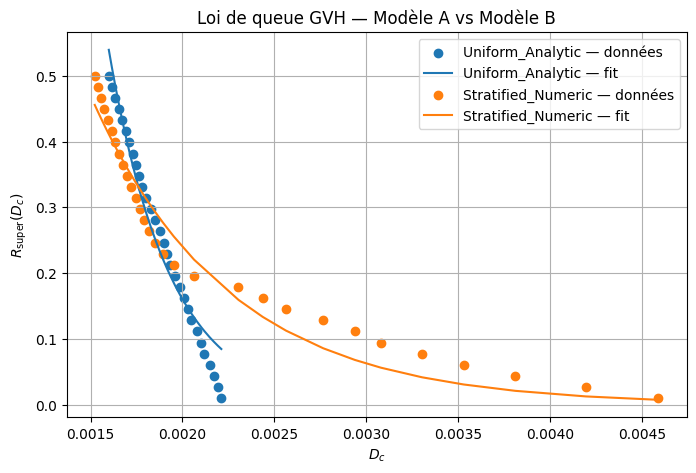

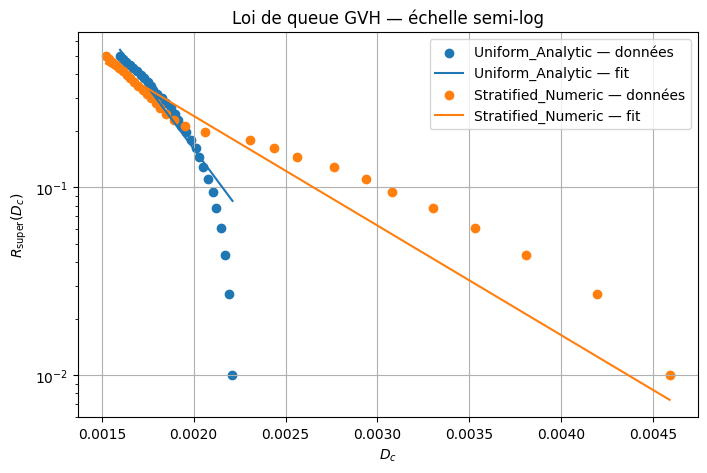

In [ ]:
# ============================================================
# Cellule 18 — Visualisation de la loi de queue GVH
# R_super(D_c) ≈ A_H exp(-B_H D_c)
# ============================================================

plt.figure(figsize=(8, 5))

for model_name in ["Uniform_Analytic", "Stratified_Numeric"]:
    sub = df_tail_all[df_tail_all["Model"] == model_name]

    plt.scatter(
        sub["D_c"],
        sub["R_super"],
        label=f"{model_name} — données"
    )

    plt.plot(
        sub["D_c"],
        sub["R_super_fit"],
        label=f"{model_name} — fit"
    )

plt.xlabel(r"$D_c$")
plt.ylabel(r"$R_{\rm super}(D_c)$")
plt.title("Loi de queue GVH — Modèle A vs Modèle B")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Version semi-log
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for model_name in ["Uniform_Analytic", "Stratified_Numeric"]:
    sub = df_tail_all[df_tail_all["Model"] == model_name]

    plt.scatter(
        sub["D_c"],
        sub["R_super"],
        label=f"{model_name} — données"
    )

    plt.plot(
        sub["D_c"],
        sub["R_super_fit"],
        label=f"{model_name} — fit"
    )

plt.yscale("log")

plt.xlabel(r"$D_c$")
plt.ylabel(r"$R_{\rm super}(D_c)$")
plt.title("Loi de queue GVH — échelle semi-log")
plt.legend()
plt.grid(True)
plt.show()

Cellule 19, cellule code Python.

In [ ]:
# ============================================================
# Cellule 19 — Observables angulaires GVH
# theta_mean, theta_max, R_180
# ============================================================

def compute_angular_gvh_observables(df_gvh, model_name, theta_threshold_deg=170):
    """
    Calcule les observables angulaires GVH à partir des vecteurs :

        Delta X_i = X_{i+1} - X_i

    puis :

        theta_i = arccos( Delta X_i . Delta X_{i+1}
                          / (||Delta X_i|| ||Delta X_{i+1}||) )

    Observables :
        theta_mean
        theta_max
        R_180 = fraction des angles > theta_threshold_deg
    """

    angle_rows = []
    summary_rows = []

    for b_ratio, sub in df_gvh.groupby("b_over_R"):
        sub = sub.sort_values("t_s").reset_index(drop=True)

        X = sub[["x_norm", "v_norm", "a_norm"]].to_numpy()

        dX = np.diff(X, axis=0)

        dX1 = dX[:-1]
        dX2 = dX[1:]

        norm1 = np.linalg.norm(dX1, axis=1)
        norm2 = np.linalg.norm(dX2, axis=1)

        valid = (norm1 > 0) & (norm2 > 0)

        cos_theta = np.full(len(dX1), np.nan)
        cos_theta[valid] = np.sum(dX1[valid] * dX2[valid], axis=1) / (
            norm1[valid] * norm2[valid]
        )

        cos_theta = np.clip(cos_theta, -1.0, 1.0)

        theta_deg = np.degrees(np.arccos(cos_theta))

        t_mid = 0.5 * (
            sub["t_s"].to_numpy()[2:] +
            sub["t_s"].to_numpy()[:-2]
        )

        df_angle_b = pd.DataFrame({
            "Model": model_name,
            "b_over_R": b_ratio,
            "t_s": t_mid,
            "t_min": t_mid / 60,
            "theta_deg": theta_deg
        })

        angle_rows.append(df_angle_b)

        theta_clean = theta_deg[np.isfinite(theta_deg)]

        summary_rows.append({
            "Model": model_name,
            "b_over_R": b_ratio,
            "theta_mean": np.mean(theta_clean),
            "theta_median": np.median(theta_clean),
            "theta_max": np.max(theta_clean),
            "R_180": np.mean(theta_clean > theta_threshold_deg),
            "theta_threshold_deg": theta_threshold_deg,
            "N_theta": len(theta_clean)
        })

    df_angles = pd.concat(angle_rows, ignore_index=True)
    summary_angles = pd.DataFrame(summary_rows)

    return df_angles, summary_angles


df_angles_uniform, summary_angles_uniform = compute_angular_gvh_observables(
    df_uniform_gvh,
    model_name="Uniform_Analytic",
    theta_threshold_deg=170
)

df_angles_stratified, summary_angles_stratified = compute_angular_gvh_observables(
    df_stratified_gvh,
    model_name="Stratified_Numeric",
    theta_threshold_deg=170
)

df_angles_all = pd.concat(
    [df_angles_uniform, df_angles_stratified],
    ignore_index=True
)

summary_angles_by_tunnel = pd.concat(
    [summary_angles_uniform, summary_angles_stratified],
    ignore_index=True
)

summary_angles_by_tunnel

,Model,b_over_R,theta_mean,theta_median,theta_max,R_180,theta_threshold_deg,N_theta
0,Uniform_Analytic,0.0,0.090026,0.084873,0.127343,0.0,170,1998
1,Uniform_Analytic,0.1,0.090026,0.084873,0.127343,0.0,170,1998
2,Uniform_Analytic,0.2,0.090026,0.084873,0.127343,0.0,170,1998
3,Uniform_Analytic,0.3,0.090026,0.084873,0.127343,0.0,170,1998
4,Uniform_Analytic,0.4,0.090026,0.084873,0.127343,0.0,170,1998
5,Uniform_Analytic,0.5,0.090026,0.084873,0.127343,0.0,170,1998
6,Uniform_Analytic,0.6,0.090026,0.084873,0.127343,0.0,170,1998
7,Uniform_Analytic,0.7,0.090026,0.084873,0.127343,0.0,170,1998
8,Uniform_Analytic,0.8,0.090026,0.084873,0.127343,0.0,170,1998
9,Uniform_Analytic,0.9,0.090026,0.084873,0.127343,0.0,170,1998


Cellule 20, code Python.

In [ ]:
# ============================================================
# Cellule 20 — Synthèse globale finale des observables GVH
# ============================================================

def compute_global_angular_summary(df_angles, model_name, theta_threshold_deg=170):
    """
    Synthèse globale des observables angulaires pour un modèle complet.
    """

    theta = df_angles["theta_deg"].to_numpy()
    theta = theta[np.isfinite(theta)]

    return {
        "Model": model_name,
        "theta_mean": np.mean(theta),
        "theta_median": np.median(theta),
        "theta_max": np.max(theta),
        "R_180": np.mean(theta > theta_threshold_deg),
        "theta_threshold_deg": theta_threshold_deg,
        "N_theta": len(theta)
    }


summary_angles_global = pd.DataFrame([
    compute_global_angular_summary(
        df_angles_uniform,
        "Uniform_Analytic"
    ),
    compute_global_angular_summary(
        df_angles_stratified,
        "Stratified_Numeric"
    )
])

# ------------------------------------------------------------
# Fusion des observables globales
# ------------------------------------------------------------

summary_final_gvh = summary_global_gvh.merge(
    summary_tail_gvh[["Model", "A_H", "B_H", "R2_tail_fit"]],
    on="Model",
    how="left"
).merge(
    summary_angles_global[
        ["Model", "theta_mean", "theta_median", "theta_max", "R_180"]
    ],
    on="Model",
    how="left"
)

# Réorganisation des colonnes
summary_final_gvh = summary_final_gvh[
    [
        "Model",
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "R_super",
        "A_H",
        "B_H",
        "R2_tail_fit",
        "theta_mean",
        "theta_median",
        "theta_max",
        "R_180"
    ]
]

summary_final_gvh

,Model,D_T_mean,S_T,S_T_norm,D_c,R_super,A_H,B_H,R2_tail_fit,theta_mean,theta_median,theta_max,R_180
0,Uniform_Analytic,0.001579,0.000395,0.250495,0.002096,0.1,68.142266,3025.666037,0.959919,0.090026,0.084873,0.127343,0.0
1,Stratified_Numeric,0.001758,0.000831,0.472850,0.003042,0.1,3.526869,1343.733131,0.956753,0.114299,0.090107,31.560064,0.0


Cellule 21, code Python.

In [ ]:
# ============================================================
# Cellule 21 — Export CSV des résultats GVH Gravity-Train
# ============================================================

output_prefix = "GVH_GravityTrain_Benchmark_0.1"

summary_crossing_stratified.to_csv(
    f"{output_prefix}_CrossingTimes.csv",
    index=False
)

summary_DT_by_tunnel.to_csv(
    f"{output_prefix}_DT_ByTunnel.csv",
    index=False
)

df_DT_compare.to_csv(
    f"{output_prefix}_DT_Comparison.csv",
    index=False
)

summary_global_gvh.to_csv(
    f"{output_prefix}_Global_GVH_Core.csv",
    index=False
)

summary_tail_gvh.to_csv(
    f"{output_prefix}_TailLaw.csv",
    index=False
)

summary_angles_by_tunnel.to_csv(
    f"{output_prefix}_Angles_ByTunnel.csv",
    index=False
)

summary_final_gvh.to_csv(
    f"{output_prefix}_Final_Observables.csv",
    index=False
)

print("Exports terminés :")
print(f"- {output_prefix}_CrossingTimes.csv")
print(f"- {output_prefix}_DT_ByTunnel.csv")
print(f"- {output_prefix}_DT_Comparison.csv")
print(f"- {output_prefix}_Global_GVH_Core.csv")
print(f"- {output_prefix}_TailLaw.csv")
print(f"- {output_prefix}_Angles_ByTunnel.csv")
print(f"- {output_prefix}_Final_Observables.csv")

Exports terminés :
- GVH_GravityTrain_Benchmark_0.1_CrossingTimes.csv
- GVH_GravityTrain_Benchmark_0.1_DT_ByTunnel.csv
- GVH_GravityTrain_Benchmark_0.1_DT_Comparison.csv
- GVH_GravityTrain_Benchmark_0.1_Global_GVH_Core.csv
- GVH_GravityTrain_Benchmark_0.1_TailLaw.csv
- GVH_GravityTrain_Benchmark_0.1_Angles_ByTunnel.csv
- GVH_GravityTrain_Benchmark_0.1_Final_Observables.csv


# Conclusion

Ce notebook construit un benchmark GVH Dynamic appliqué au problème du *gravity train* dans deux modèles terrestres.

Le **Modèle A**, correspondant à une Terre homogène idéale, reproduit l’invariance analytique classique : tous les tunnels rectilignes possèdent le même temps de traversée, malgré des longueurs géométriques différentes.

Le **Modèle B**, correspondant à une Terre radialement stratifiée, introduit une rupture contrôlée de cette invariance harmonique. Les temps de traversée deviennent dépendants du paramètre d’impact \(b/R\), avec une variation systématique entre les tunnels profonds et les tunnels proches de la surface.

Les observables GVH confirment cette rupture :

\[
S_T^{norm}: 0.2505 \rightarrow 0.4729
\]

\[
D_c: 0.002096 \rightarrow 0.003042
\]

\[
B_H: 3025.67 \rightarrow 1343.73
\]

\[
\theta_{\max}: 0.127^\circ \rightarrow 31.56^\circ
\]

Ces résultats indiquent que la stratification terrestre élargit la distribution dynamique GVH, ralentit la décroissance de la queue \(R_{\rm super}(D_c)\), et produit des ruptures angulaires locales dans l’espace des états dynamiques.

En revanche :

\[
R_{180}=0
\]

dans les deux modèles. Il n’y a donc pas d’opposition angulaire extrême dans ce benchmark.

Le résultat principal est :

\[
\boxed{
\text{GVH Dynamic détecte la rupture de l’invariance harmonique induite par la stratification radiale.}
}
\]

Ce benchmark est indépendant de toute interprétation par Volume Partagé. Il constitue une validation méthodologique de GVH Dynamic sur un système possédant une référence analytique connue.

Le benchmark 0.1 valide la chaîne de calcul sur des cas classiques connus et montre que les observables GVH réagissent de manière cohérente à une rupture contrôlée de l’invariance harmonique. Il établit donc une preuve de sensibilité descriptive, tandis que la fiabilité comme détecteur nécessitera une version 0.2 avec convergence numérique, robustesse au bruit et seuils de décision calibrés.